In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from optbinning import OptimalBinning, BinningProcess

In [3]:
df= pd.read_csv("../data/german_credit_data_mapping.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Checking_Account_Status  1000 non-null   object
 1   Duration                 1000 non-null   int64 
 2   Credit_History           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_Amount            1000 non-null   int64 
 5   Savings_Account          1000 non-null   object
 6   Employment_Duration      1000 non-null   object
 7   Installment_Rate         1000 non-null   int64 
 8   Personal_Status_Sex      1000 non-null   object
 9   Other_Debtors            1000 non-null   object
 10  Residence_Duration       1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_Installment_Plans  1000 non-null   object
 14  Housing                  1000 non-null   

Separate the columns, the categorical and numerical.

In [5]:
X= df.drop("Target", axis=1)
y= df["Target"]
num_cols= X.select_dtypes(include="int64").columns.tolist()
all_cols_num= df.select_dtypes(include="int64").columns.tolist() #to include target variable
cat_cols= X.select_dtypes(include="object").columns.tolist()

observe the distribution of the target variable with a pie chart

In [6]:
def target_distribution(y):
    y1=y.copy()
    y1.replace({0: "Good Credit", 1: "Bad Credit"}, inplace=True)
    data= y1.value_counts()
    labels= data.index
    sizes= data.values
    plt.pie(sizes, labels=labels, autopct="%1.1f%%")
    plt.title(y.name + " Distribution")
    plt.show()

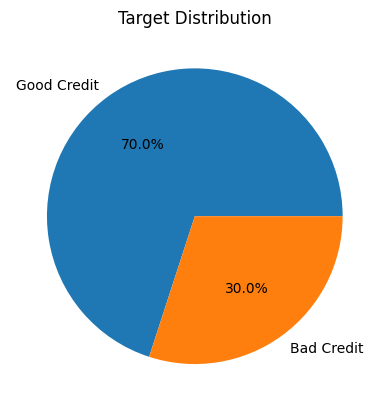

In [7]:
target_distribution(y)

In [8]:
def hist_num_cols(data, num_cols,target):
    len_cols= len(num_cols)
    optimal_rows= int(np.ceil(len_cols/2))
    fig, axes = plt.subplots(optimal_rows, 2, figsize=(20, 30))
    for i, col in enumerate(num_cols):
        ax = axes[i//2, i%2]
        sns.histplot(data=data, x=col, hue=target, ax=ax,kde=True)
        ax.set_title(f'Distribution of {col} by {target.name}', fontsize=20)
        ax.legend(['Good Credit', 'Bad Credit'])
    plt.tight_layout()
    plt.show()

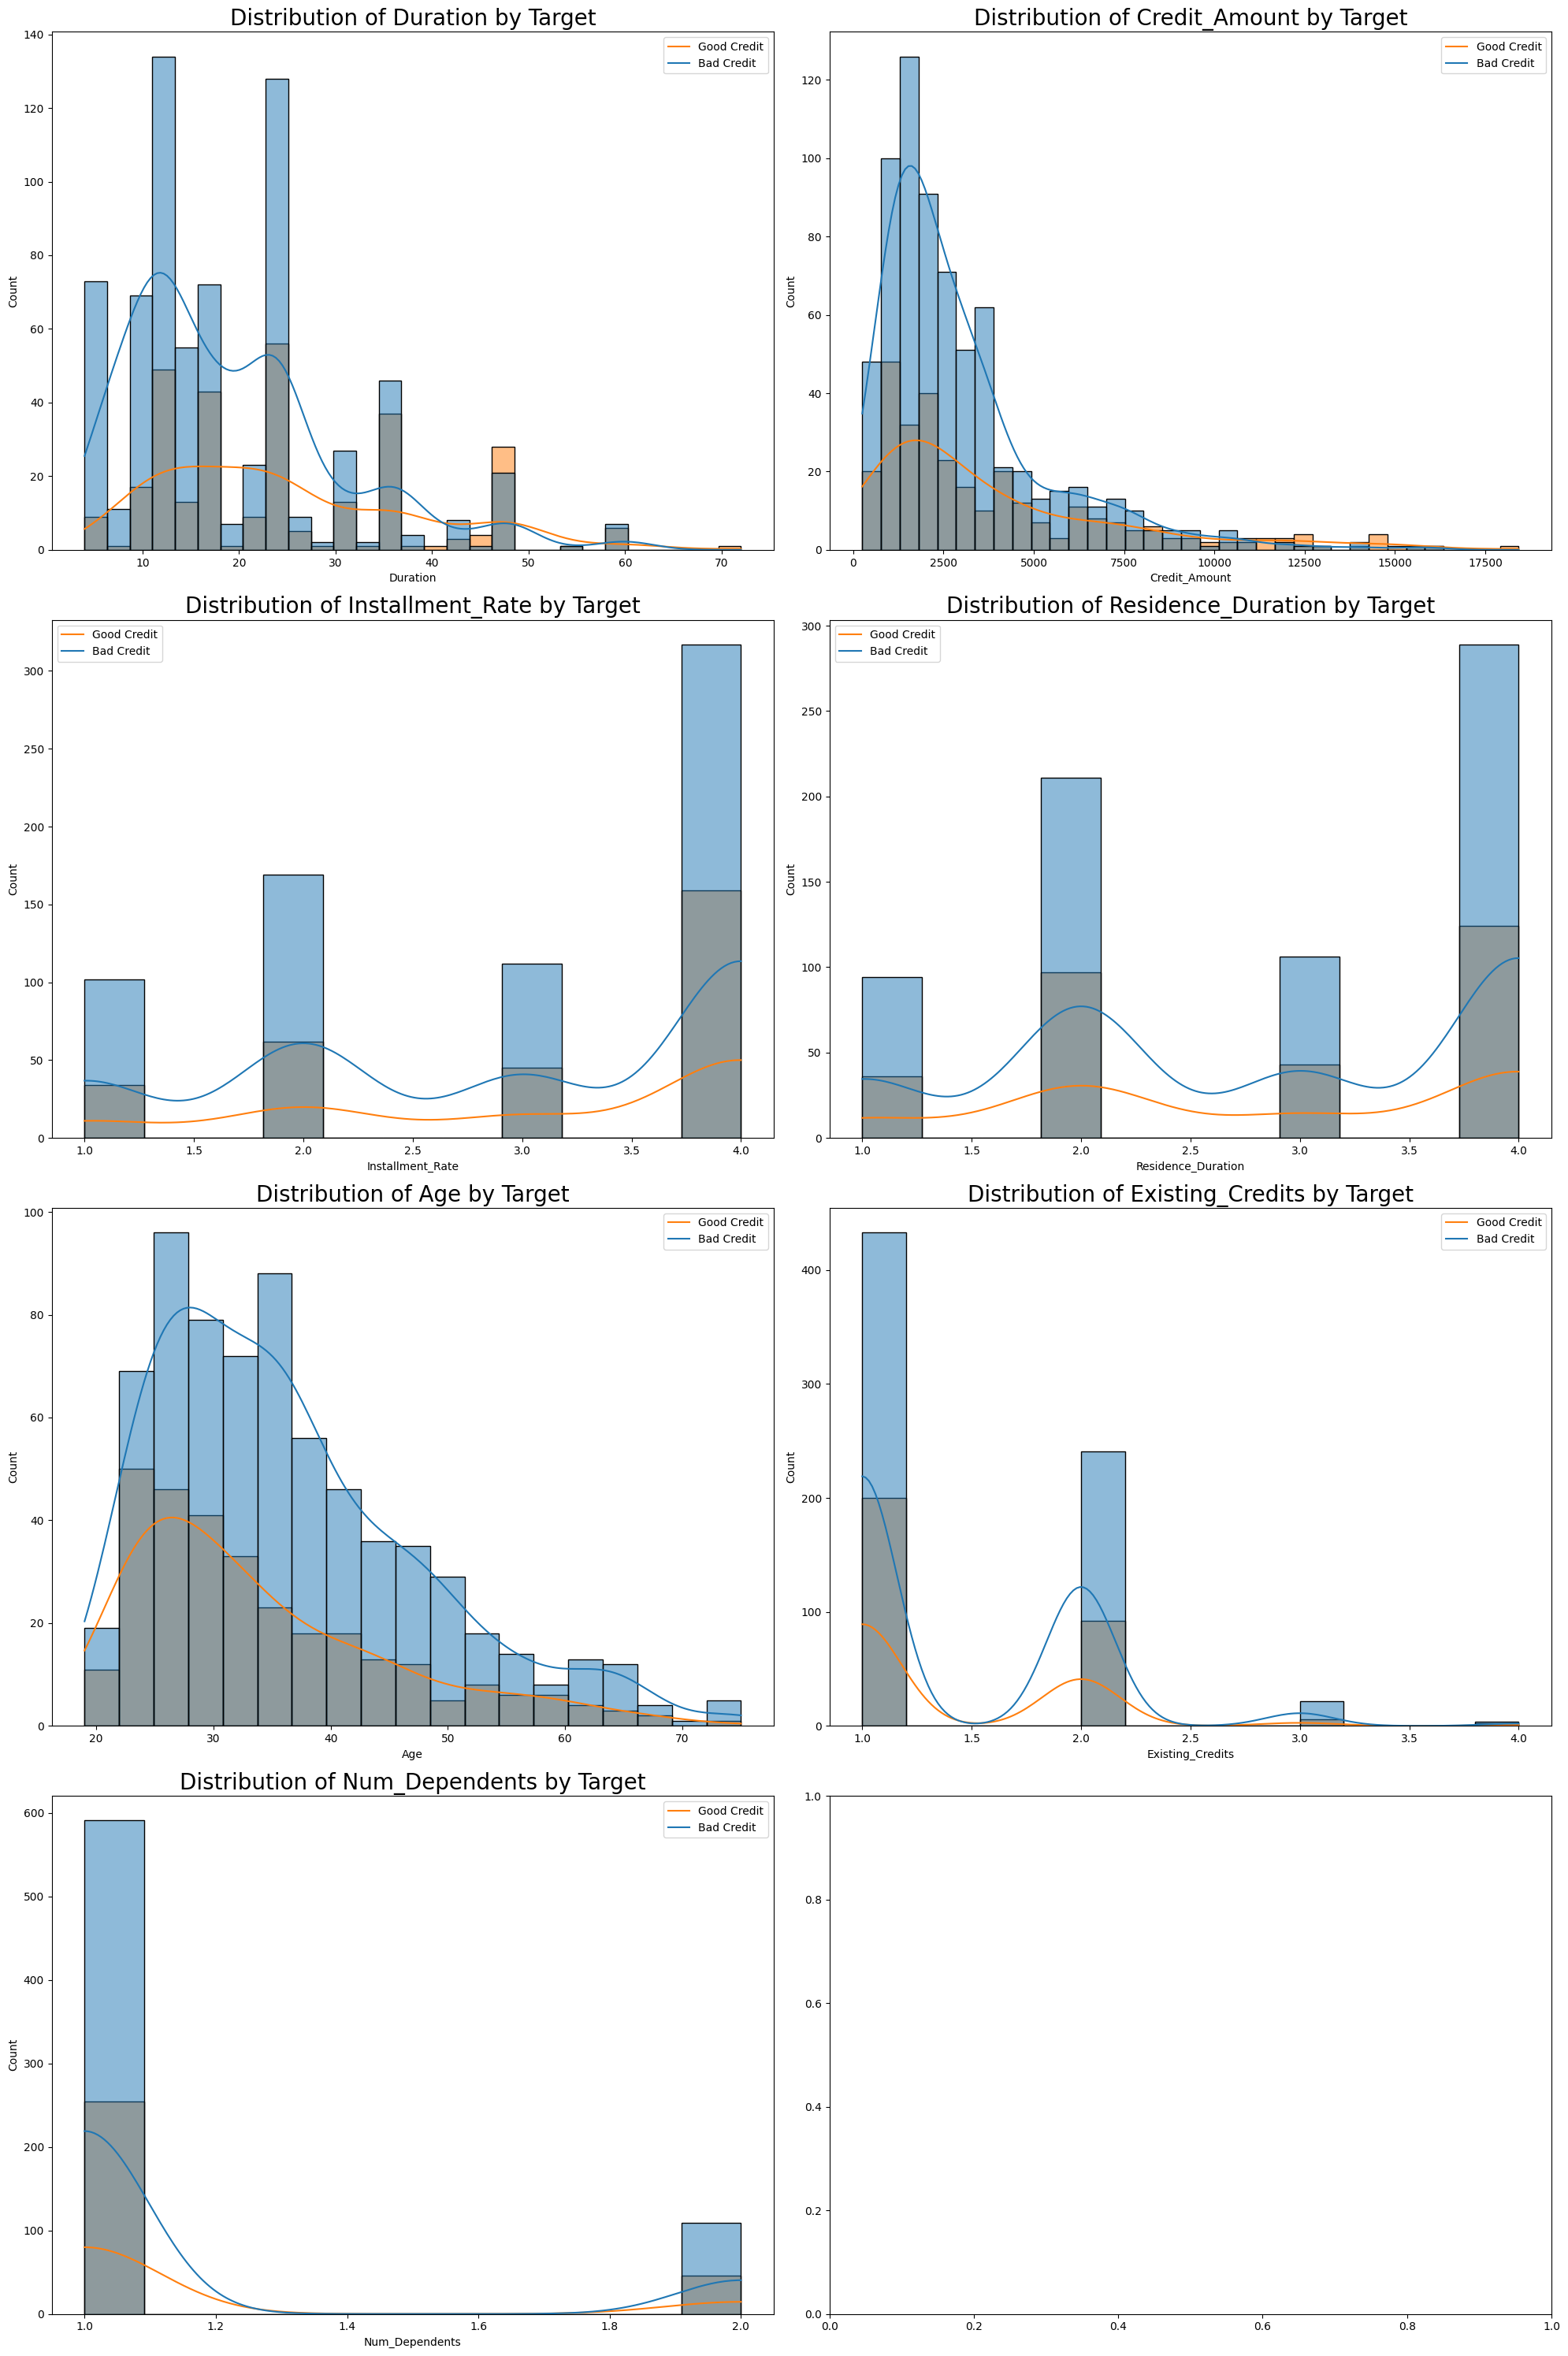

In [9]:
hist_num_cols(X, num_cols, y)

In [10]:
def binningimportance(df,num_cols, target_col):

    for col in num_cols:
        print(f"\n Processing: {col}")
        print("-" * 40)
    
        optb= OptimalBinning(name=col, dtype="numerical", solver="cp", monotonic_trend="auto_asc_desc")
        optb.fit(df[col], df[target_col])
        binning_table = optb.binning_table.build()
        display(binning_table)
        iv = binning_table.loc['Totals', 'IV']
    
        if iv >= 0.3:
            strength = "Strong predictor"
        elif iv >= 0.1:
            strength = "Medium predictor"
        elif iv >= 0.02:
            strength = "Weak predictor"
        else:
            strength = "Not useful"
        print(f"\n Total IV: {iv:.4f} - {strength}")
        print("=" * 80)

In [11]:
binningimportance(df, num_cols, "Target")


 Processing: Duration
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 8.50)",94,0.094,84,10,0.106383,1.280934,0.111014,0.013000
1,"[8.50, 11.50)",86,0.086,69,17,0.197674,0.553595,0.023198,0.002863
2,"[11.50, 15.50)",251,0.251,189,62,0.247012,0.267315,0.016930,0.002110
3,"[15.50, 26.50)",340,0.340,231,109,0.320588,-0.096228,0.003208,0.000401
4,"[26.50, 34.50)",59,0.059,39,20,0.338983,-0.179468,0.001966,0.000245
5,"[34.50, 43.50)",100,0.100,58,42,0.420000,-0.524524,0.029973,0.003704
6,"[43.50, inf)",70,0.070,30,40,0.571429,-1.13498,0.102689,0.012189
7,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.288977,0.034512



 Total IV: 0.2890 - Medium predictor

 Processing: Credit_Amount
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 718.00)",54,0.054,41,13,0.240741,0.301325,0.004592,0.000572
1,"[718.00, 3913.50)",686,0.686,510,176,0.256560,0.216629,0.030741,0.003835
2,"[3913.50, 6322.50)",127,0.127,79,48,0.377953,-0.349051,0.016455,0.002047
3,"[6322.50, 7839.50)",58,0.058,36,22,0.379310,-0.354821,0.007772,0.000966
4,"[7839.50, inf)",75,0.075,34,41,0.546667,-1.034509,0.091135,0.010910
5,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.150695,0.018330



 Total IV: 0.1507 - Medium predictor

 Processing: Installment_Rate
----------------------------------------


...


 Total IV: 0.1002 - Medium predictor

 Processing: Existing_Credits
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.50)",633,0.633,433,200,0.315956,-0.074877,0.003601,0.00045
1,"[1.50, inf)",367,0.367,267,100,0.272480,0.134781,0.006482,0.00081
2,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.00000
3,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.00000
Totals,,1000,1.000,700,300,0.300000,,0.010084,0.00126



 Total IV: 0.0101 - Not useful

 Processing: Num_Dependents
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.50)",845,0.845,591,254,0.300592,-0.002816,0.000007,8.381277e-07
1,"[1.50, inf)",155,0.155,109,46,0.296774,0.015409,0.000037,4.585855e-06
2,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000e+00
3,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000e+00
Totals,,1000,1.000,700,300,0.300000,,0.000043,5.423983e-06



 Total IV: 0.0000 - Not useful


In [12]:
def correlation_plot(df, all_cols_num):
    corr_matrix = df[all_cols_num].corr()
        
    # Máscara para la diagonal superior
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Matrix-Numerical Features", fontsize=16)
    plt.show()

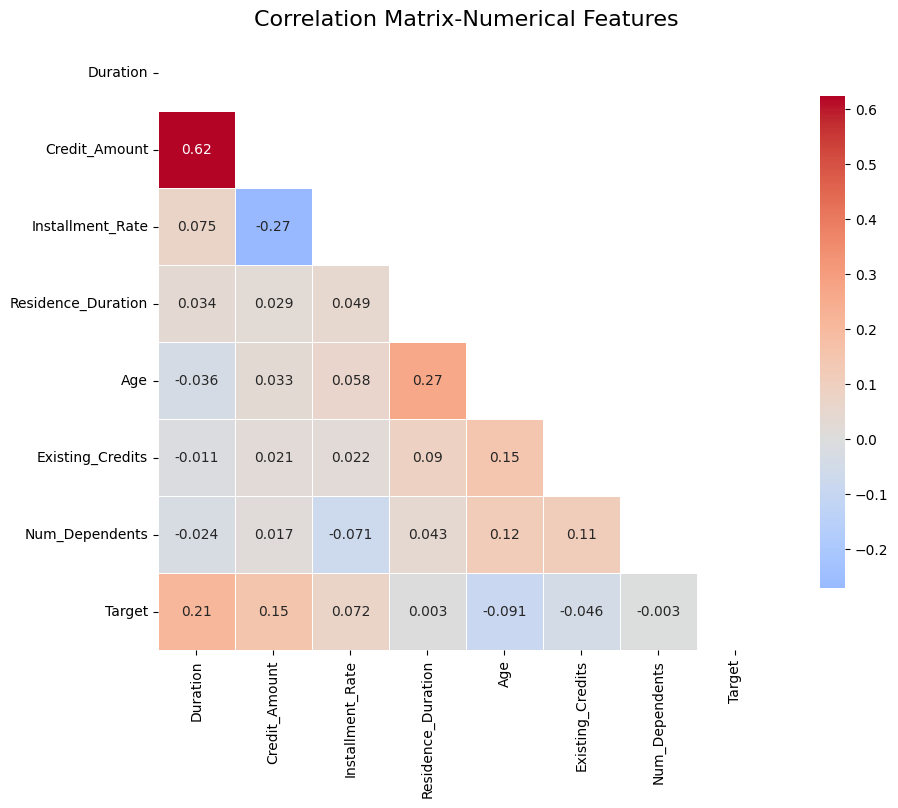

In [13]:
correlation_plot(df, all_cols_num)

In [14]:
def cat_cols_graphs(data, cat_cols, target):
    len_cols= len(cat_cols)
    optimal_rows= int(np.ceil(len_cols/2))
    fig, axes = plt.subplots(optimal_rows, 2, figsize=(20,40))
    for i,col in enumerate(cat_cols):
        ax = axes[i//2, i%2]
        sns.countplot(data=data, y=col, hue=target, ax=ax)
        ax.set_title(f'Countplot of {col} by {target.name}', fontsize=20)
        ax.legend(['Good Credit', 'Bad Credit'])
    plt.tight_layout()
    plt.suptitle('Categorical Feature Analysis by Target Class', fontsize=30, fontweight='bold', y=1.02)
    plt.show()
    

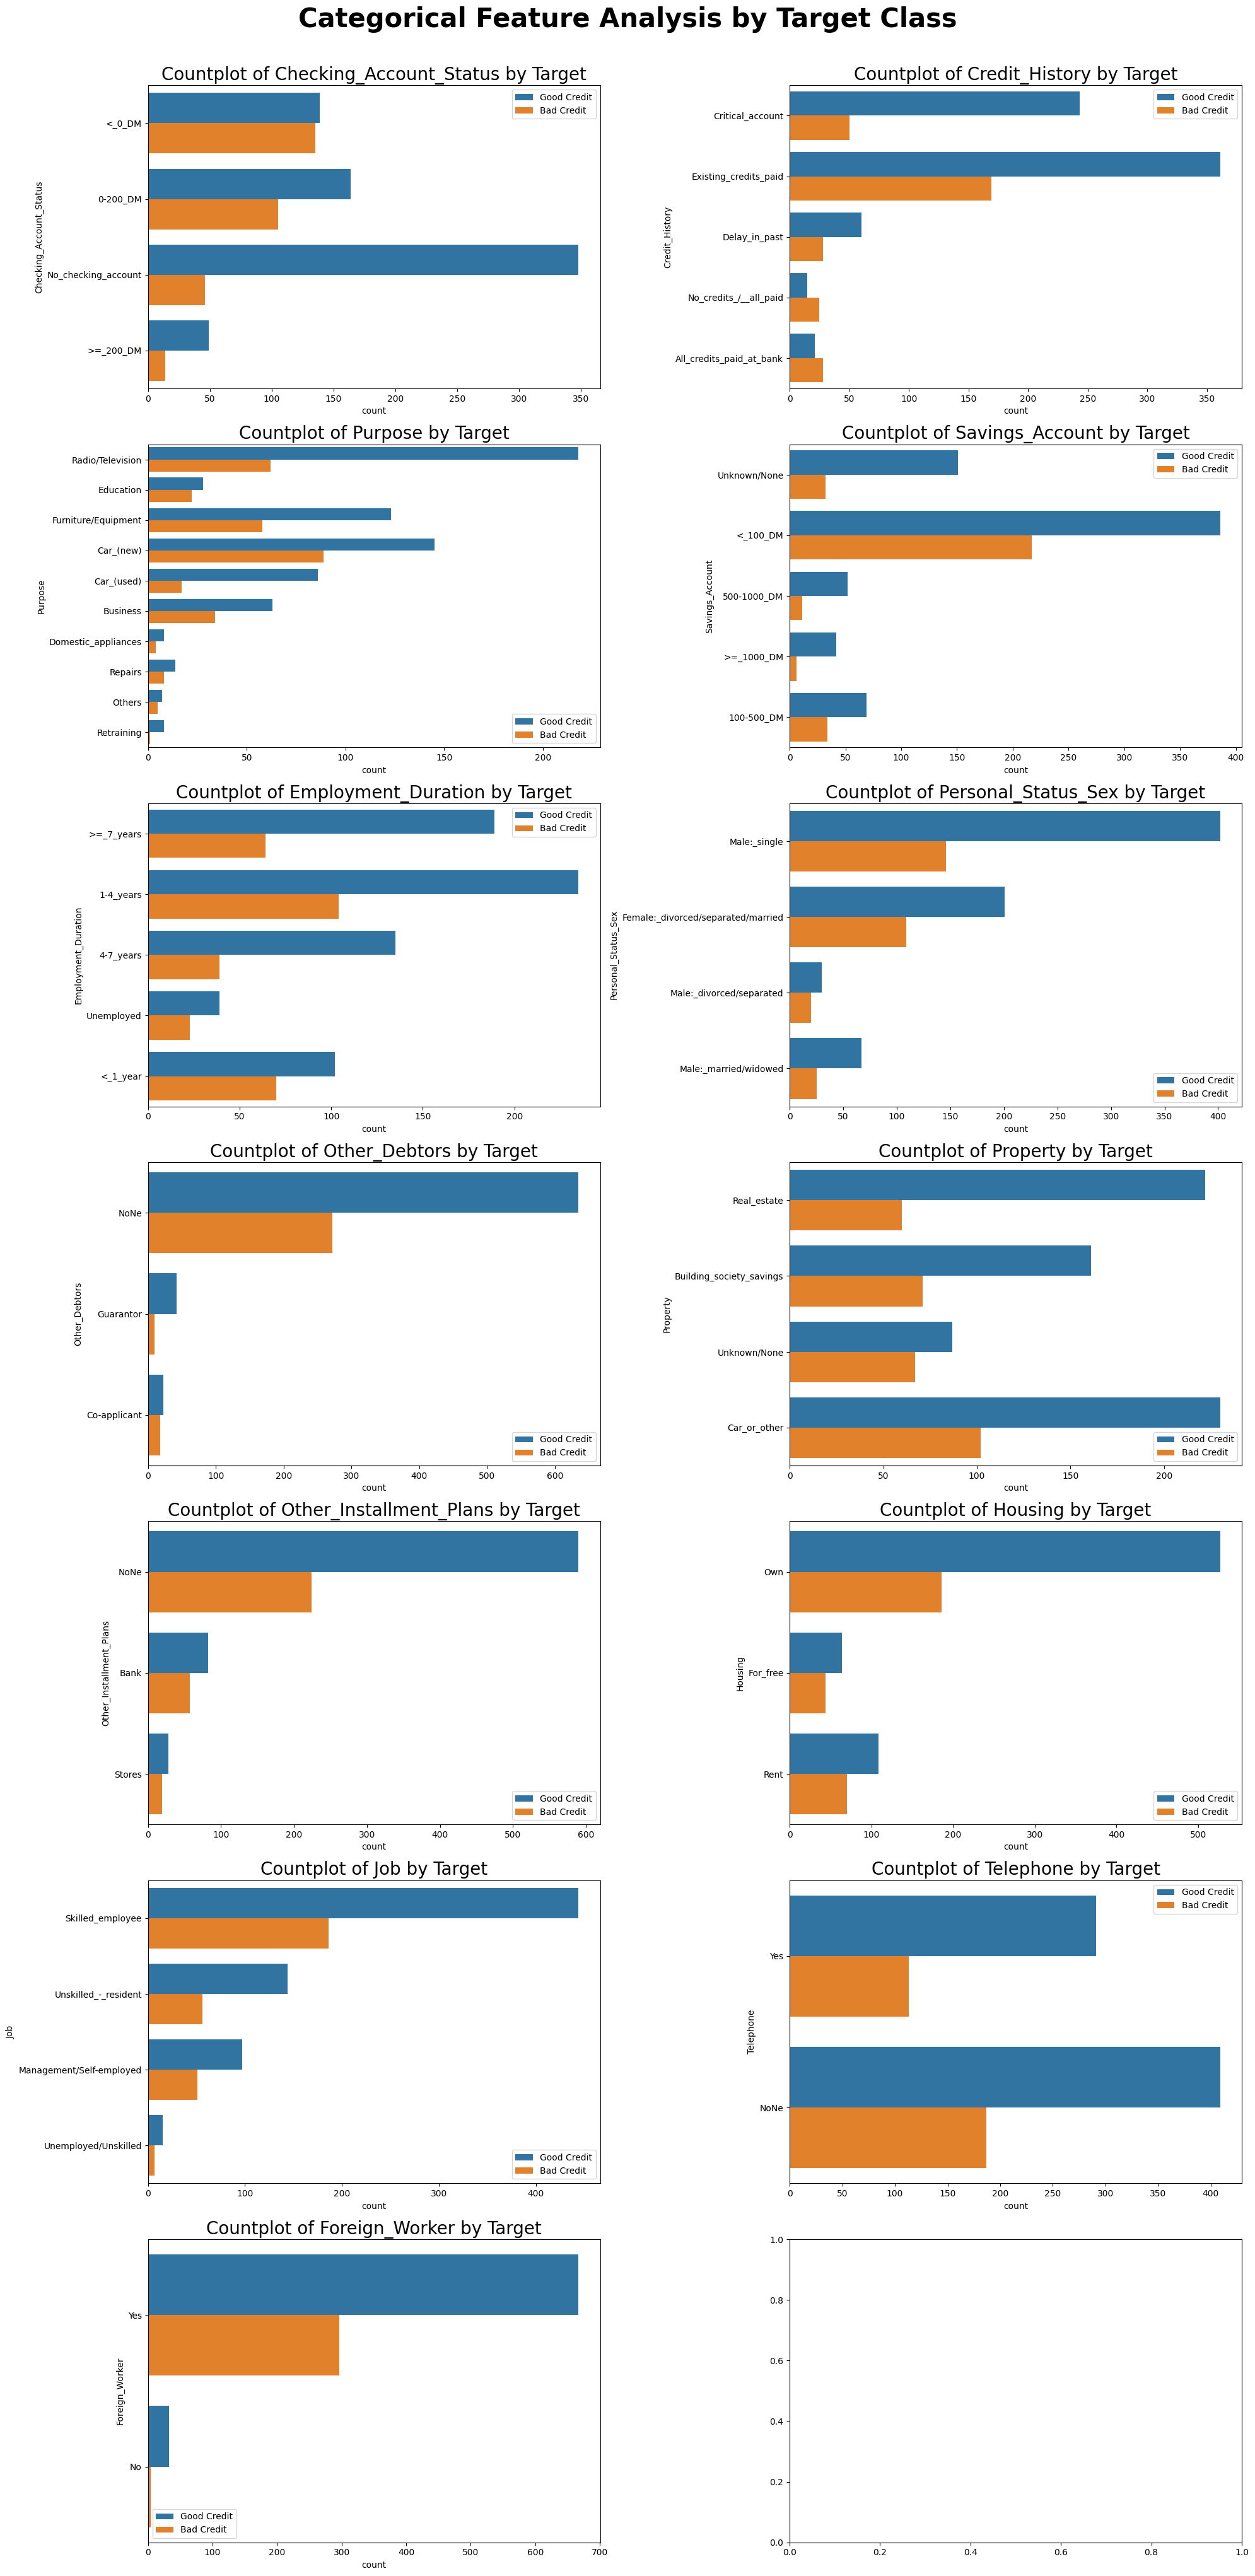

In [15]:
cat_cols_graphs(X, cat_cols, y)

In [27]:

def binningimportance_cat(df, cat_cols, target_col):

    for col in cat_cols:
        print(f"\n Processing: {col}")
        print("-" * 40)
    
        optb= OptimalBinning(name=col, dtype="categorical", solver="mip")
        optb.fit(df[col], df[target_col])
        binning_table = optb.binning_table.build()
        display(binning_table)
        iv = binning_table.loc['Totals', 'IV']
    
        if iv >= 0.3:
            strength = "Strong predictor"
        elif iv >= 0.1:
            strength = "Medium predictor"
        elif iv >= 0.02:
            strength = "Weak predictor"
        else:
            strength = "Not useful"
        print(f"\n Total IV: {iv:.4f} - {strength}")
        print("=" * 80)

In [28]:
binningimportance_cat(df, cat_cols, "Target")


 Processing: Checking_Account_Status
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[No_checking_account],394,0.394,348,46,0.116751,1.176263,0.404410,0.047825
1,[>=_200_DM],63,0.063,49,14,0.222222,0.405465,0.009461,0.001175
2,[0-200_DM],269,0.269,164,105,0.390335,-0.401392,0.046447,0.005767
3,[<_0_DM],274,0.274,139,135,0.492701,-0.818099,0.205693,0.025018
4,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.666012,0.079784



 Total IV: 0.6660 - Strong predictor

 Processing: Credit_History
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[Critical_account],293,0.293,243,50,0.170648,0.733741,0.132423,0.016191
1,[Delay_in_past],88,0.088,60,28,0.318182,-0.085158,0.000649,0.000081
2,[Existing_credits_paid],530,0.530,361,169,0.318868,-0.088319,0.004206,0.000526
3,"[All_credits_paid_at_bank, No_credits_/__all_p...",89,0.089,36,53,0.595506,-1.234071,0.154553,0.018180
4,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.291830,0.034977



 Total IV: 0.2918 - Medium predictor

 Processing: Purpose
----------------------------------------


...


 Total IV: 0.0085 - Not useful

 Processing: Telephone
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[Yes],404,0.404,291,113,0.279703,0.098638,0.003852,0.000481
1,[NoNe],596,0.596,409,187,0.313758,-0.064691,0.002526,0.000316
2,Special,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,1000,1.000,700,300,0.300000,,0.006378,0.000797



 Total IV: 0.0064 - Not useful

 Processing: Foreign_Worker
----------------------------------------


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[No, Yes]",1000,1.0,700,300,0.3,0.0,0.0,0.0
1,Special,0,0.0,0,0,0.0,0.0,0.0,0.0
2,Missing,0,0.0,0,0,0.0,0.0,0.0,0.0
Totals,,1000,1.0,700,300,0.3,,0.0,0.0



 Total IV: 0.0000 - Not useful


In [29]:
all_features = X.columns.tolist()

In [30]:
from optbinning import BinningProcess

# Definimos el criterio de selección: solo variables con IV > 0.02
# Esto filtrará las variables que no son pertinentes
selection_criteria = {
    "iv": {"min": 0.02}
}
all_features = X.columns.tolist()
binning_process = BinningProcess(
    variable_names=all_features,    # Lista de todas tus variables X
    categorical_variables=cat_cols,    # Tus variables categóricas
    selection_criteria=selection_criteria
)

# Al hacer fit, el objeto aprenderá cuáles sirven y cuáles no
binning_process.fit(X, y)

# Para ver cuáles se quedaron y cuáles se fueron:
print(binning_process.summary().query("selected == True"))

                       name        dtype   status  selected n_bins        iv  \
0   Checking_Account_Status  categorical  OPTIMAL      True      4  0.666012   
1                  Duration    numerical  OPTIMAL      True      7  0.288977   
2            Credit_History  categorical  OPTIMAL      True      4   0.29183   
3                   Purpose  categorical  OPTIMAL      True      6  0.167599   
4             Credit_Amount    numerical  OPTIMAL      True      7  0.246132   
5           Savings_Account  categorical  OPTIMAL      True      4  0.192473   
6       Employment_Duration  categorical  OPTIMAL      True      5  0.086434   
7          Installment_Rate    numerical  OPTIMAL      True      4  0.026322   
8       Personal_Status_Sex  categorical  OPTIMAL      True      4  0.044671   
11                 Property  categorical  OPTIMAL      True      4  0.112638   
12                      Age    numerical  OPTIMAL      True      7  0.130974   
13  Other_Installment_Plans  categorical